In [37]:
# Load the Dataset
from google.colab import files
uploaded = files.upload()

Saving ola_driver.csv to ola_driver (1).csv


In [38]:
#Import required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ola_driver.csv')

In [39]:
df.shape  # (Rows,Columns)

(19104, 14)

In [40]:
df.head() # Display first 5 rows of the Dataset

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [41]:
df.columns # Columns of Datasets

Index(['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City',
       'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

In [42]:
df.info() #Column names and their Data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


In [43]:
df.isnull().sum() #Count missing values in each column

,0
Unnamed: 0,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488


In [44]:
df['Driver_ID'].nunique() #Driver_ID Unique Count

2381

In [45]:
df.describe() #For Statistical Summary

,Unnamed: 0,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,9551.500000,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,5514.994107,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,0.000000,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,4775.750000,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,9551.500000,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,14327.250000,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,19103.000000,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


In [46]:
# Convert Date Columns into Datetime Format
df['MMM-YY']= pd.to_datetime(df['MMM-YY'])
df['Dateofjoining']= pd.to_datetime(df['Dateofjoining'])
df['LastWorkingDate']= pd.to_datetime(df['LastWorkingDate'])

/tmp/ipykernel_3192/3068695483.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['MMM-YY']= pd.to_datetime(df['MMM-YY'])
/tmp/ipykernel_3192/3068695483.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dateofjoining']= pd.to_datetime(df['Dateofjoining'])
/tmp/ipykernel_3192/3068695483.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['LastWorkingDate']= pd.to_datetime(df['LastWorkingDate'])


In [47]:
df.drop('Unnamed: 0', axis=1, inplace= True) #Drop first unknown column

In [48]:
print (df.shape)

(19104, 13)


In [50]:
# Create Target variable for attrition
#1 = Driver has left the company
#0 = Driver is still with the company
df["Attrition"] = df['LastWorkingDate'].notnull().astype(int)

In [51]:
df['Attrition'].value_counts() # Check distribution of target variable

,count
Attrition,
0,17488
1,1616


# Attrition Rate = Driver left/Total * 100
1616/19104* 100
=8.46%

Handle Missing Values


In [52]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_3192/1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [53]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [54]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [55]:
# Calculated driver tanure in days and for active drivers, i use 31/12/2020 as end date
df["Tenure_Days"] = (
    df["LastWorkingDate"].fillna(pd.Timestamp("2020-12-31"))
    - df["Dateofjoining"]
).dt.days

In [56]:
# Create a feature indicating whether quarterly rating increased
df["Rating_Increased"] = (
    df.groupby("Driver_ID")["Quarterly Rating"]
      .diff() > 0
).astype(int)

In [57]:
# Create a feature indicating whether monthly income increased
df["Income_Increased"] = (
    df.groupby("Driver_ID")["Income"]
      .diff() > 0
).astype(int)

#Exploratory Data Analysis


AGE DISTRIBUTION

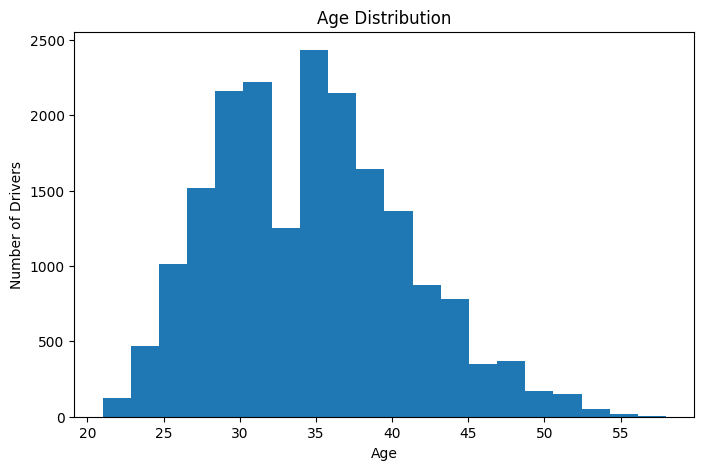

In [58]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Drivers')
plt.show()

1.The average age of drivers is 34-35 approx, with the youngest driver being 21 years and the oldest being 58 years.
 2.The median age is 34 years, indicating that the workforce is primarily composed of experienced middle-aged drivers.
 3.Since most drivers belong to this age segment, retention programs should mainly target drivers aged 30–40 years.

INCOME DISTRIBUTION

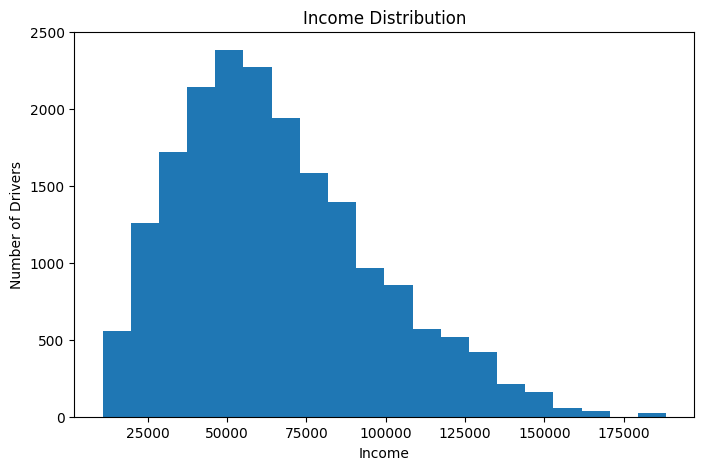

In [59]:
plt.figure(figsize=(8,5))
plt.hist(df['Income'], bins=20)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Number of Drivers')
plt.show()

The average monthly income of drivers is approximately ₹65,500.
The median income is ₹60,087, indicating that half of the drivers earn below this amount.
Driver income ranges from ₹10,700 to ₹1,88,000, showing a very large income variation among drivers.
The top 25% of drivers earn more than ₹82,000, suggesting that higher performing drivers are rewarded significantly better.

QUARTERLY RATING DISTRIBUTION

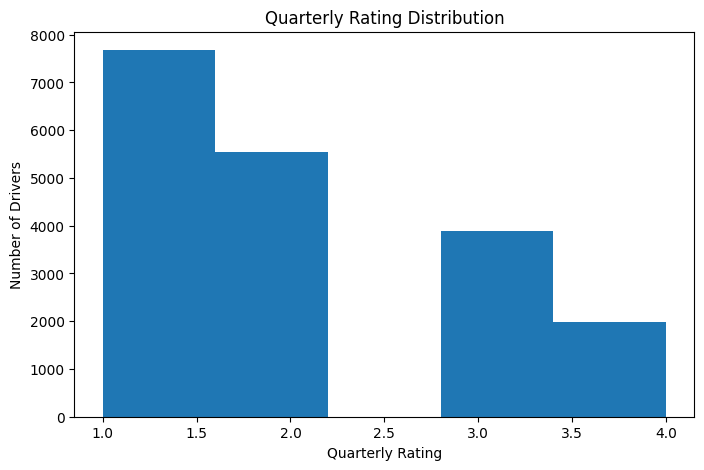

In [60]:
plt.figure(figsize=(8,5))
plt.hist(df['Quarterly Rating'], bins=5)
plt.title('Quarterly Rating Distribution')
plt.xlabel('Quarterly Rating')
plt.ylabel('Number of Drivers')
plt.show()

The average quarterly rating is approximately 2.01, which indicates moderate driver performance overall.
7,600 records (40.%) have a rating of 1, making it the most common rating.
Only 1,900 records (10.%) achieved the highest rating of 4, indicating that very few drivers consistently perform at the highest level.
The large number of low rated drivers suggests an opportunity for training and performance improvement programs.

QUARTERLY RATING VARIATION ACROSS TIME

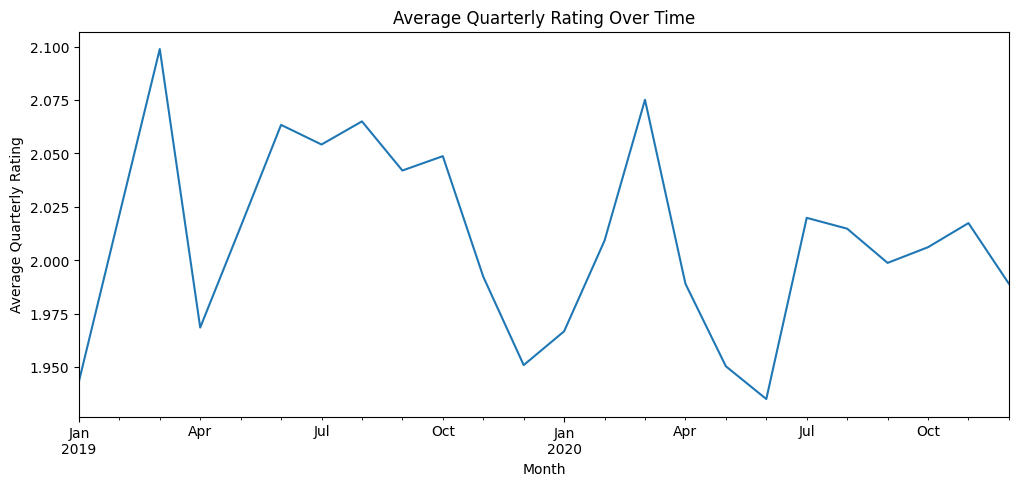

In [61]:
rating_trend = df.groupby('MMM-YY')['Quarterly Rating'].mean()

plt.figure(figsize=(12,5))
rating_trend.plot()
plt.title('Average Quarterly Rating Over Time')
plt.xlabel('Month')
plt.ylabel('Average Quarterly Rating')
plt.show()

The average quarterly rating remains relatively stable over different time periods.
Minor fluctuations in ratings indicate changes in driver performance across quarters.
Consistently low average ratings suggest opportunities for driver training and support programs.
Improving driver ratings can contribute to better customer satisfaction and retention.

MONTHLY INCOME TREND

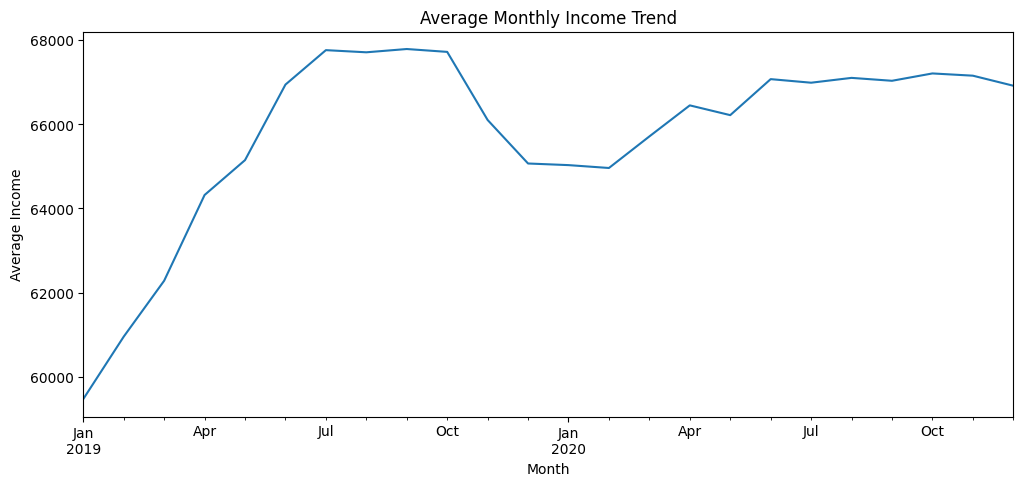

In [62]:
income_trend = df.groupby('MMM-YY')['Income'].mean()

plt.figure(figsize=(12,5))
income_trend.plot()
plt.title('Average Monthly Income Trend')
plt.xlabel('Month')
plt.ylabel('Average Income')
plt.show()

Driver income shows fluctuations over different months, indicating variability in earning opportunities.
Certain months record higher average income, possibly due to seasonal demand or promotional campaigns.
Stable income growth can positively influence driver satisfaction and retention.
Monitoring income trends can help Ola design more effective incentive programs.

MONTHLY BUSINESS VALUE TREND

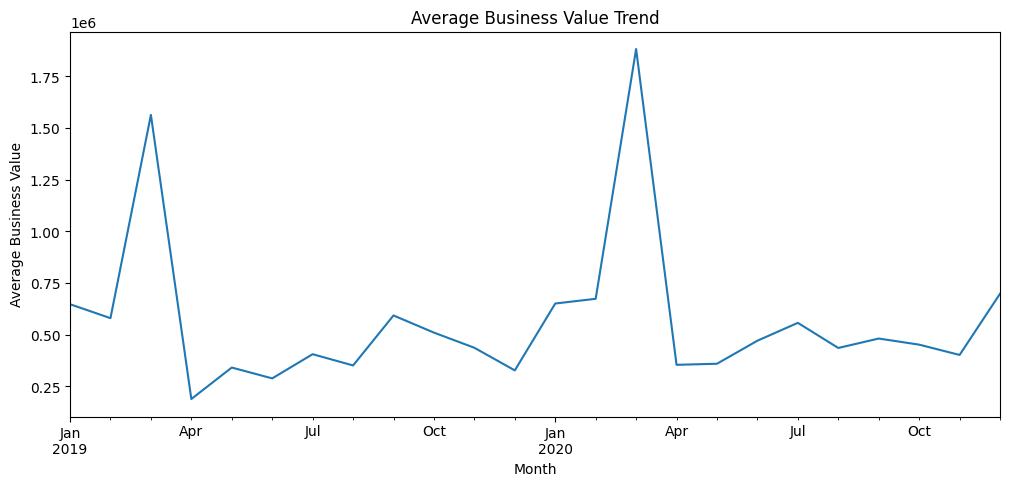

In [63]:
business_trend = df.groupby('MMM-YY')['Total Business Value'].mean()

plt.figure(figsize=(12,5))
business_trend.plot()
plt.title('Average Business Value Trend')
plt.xlabel('Month')
plt.ylabel('Average Business Value')
plt.show()

Driver income shows fluctuations over different months, indicating variability in earning opportunities.
Certain months record higher average income, possibly due to seasonal demand or promotional campaigns.
Stable income growth can positively influence driver satisfaction and retention.
Monitoring income trends can help Ola design more effective incentive programs.

TOTAL BUSINESS VALUE DISTRIBUTION

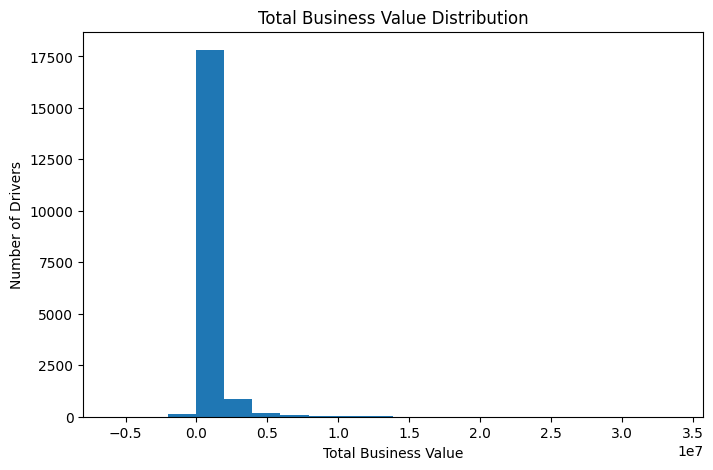

In [64]:
plt.figure(figsize=(8,5))
plt.hist(df['Total Business Value'], bins=20)
plt.title('Total Business Value Distribution')
plt.xlabel('Total Business Value')
plt.ylabel('Number of Drivers')
plt.show()

The distribution of Total Business Value is highly skewed, indicating significant variation in business generated by drivers.
Most drivers generate lower to moderate business value, while only a few drivers contribute very high business value.
Some negative business values are observed, which may indicate cancellations, refunds, or business losses.
Drivers generating lower business value may require additional support and performance improvement initiatives.

CORRELATION ANALYSIS

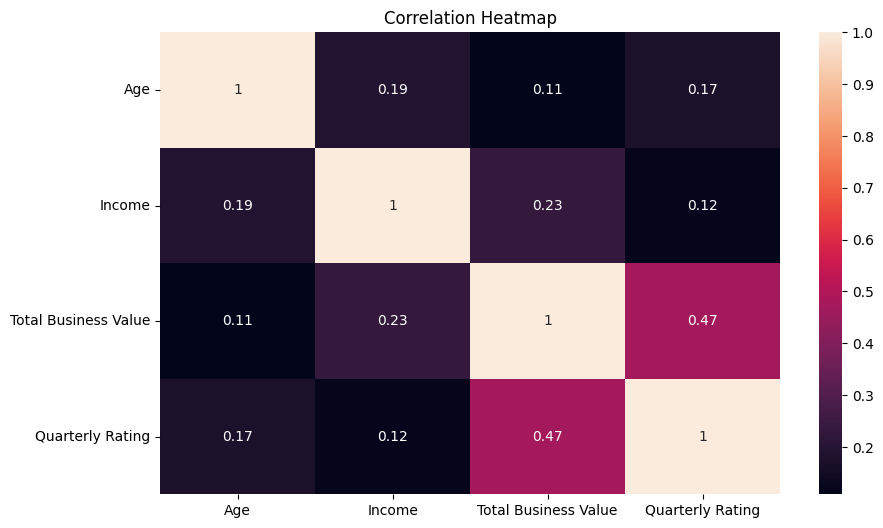

In [65]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[['Age','Income','Total Business Value',
        'Quarterly Rating']].corr(),
    annot=True
)

plt.title('Correlation Heatmap')
plt.show()

Income shows a positive relationship with Total Business Value, indicating that drivers generating more business generally earn higher incomes.
Quarterly Rating is expected to positively influence retention and driver performance.
Age has a relatively weak relationship with income and business value, suggesting that experience alone does not determine performance.

CITY WISE ATTRITION

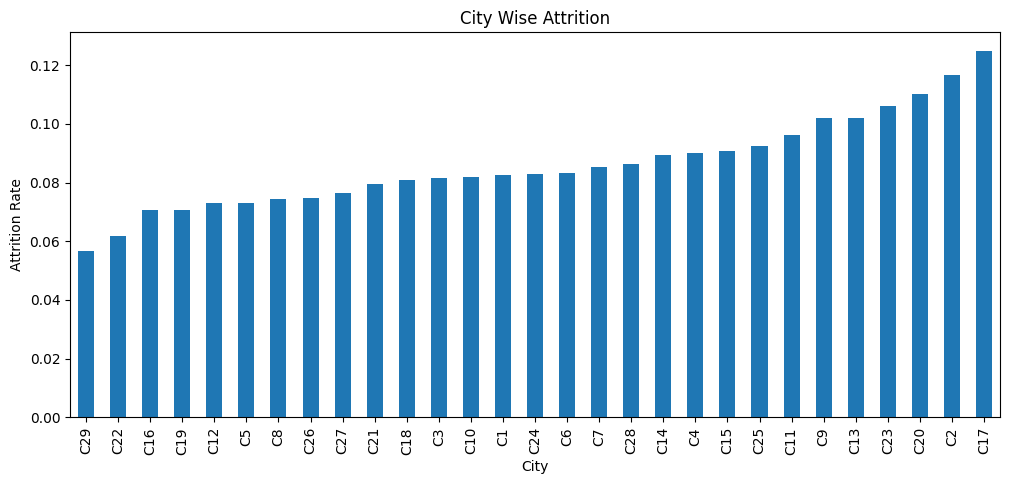

In [66]:
city_attrition = df.groupby('City')['Attrition'].mean()

city_attrition.sort_values().plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('City Wise Attrition')
plt.xlabel('City')
plt.ylabel('Attrition Rate')
plt.show()

The dataset contains drivers from 29 different cities, indicating a geographically diverse workforce.
Attrition rates vary across cities, suggesting that local market conditions may influence retention.
Some cities may require location specific retention strategies and incentive plans.

INCOME VS ATTRITION

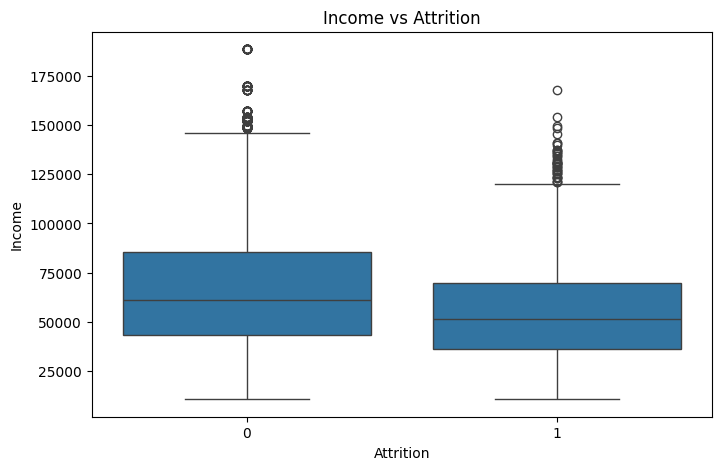

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='Income',
    data=df
)

plt.title('Income vs Attrition')
plt.show()

Drivers earning below the median income of ₹60,087 are more likely to leave the organization.
Higher income appears to improve driver retention and satisfaction.
The large salary range suggests unequal earning opportunities across drivers.
Performance linked incentives may help reduce attrition among low-income drivers.

RATING VS ATTRITION

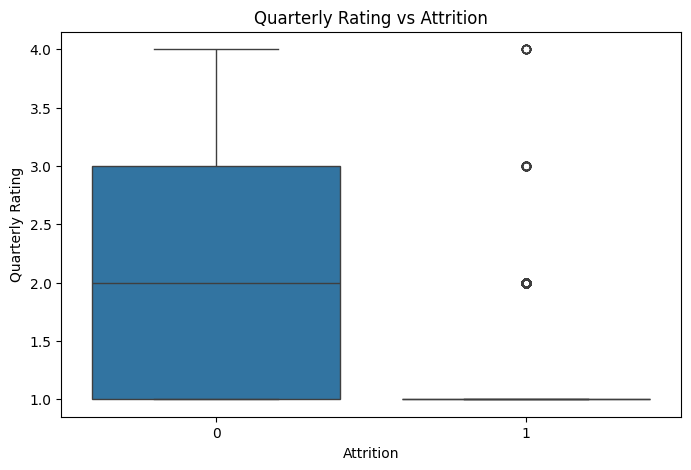

In [68]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='Quarterly Rating',
    data=df
)

plt.title('Quarterly Rating vs Attrition')
plt.show()

Drivers with ratings of 1 and 2 account for nearly 69% of all records, indicating that low performing drivers form a large portion of the workforce.
Drivers with lower ratings are more likely to leave the company compared to high performing drivers.

# BUSINESS INSIGHTS

1.The average age of drivers is 34.67 years, indicating that most drivers belong to the experienced working age group.    
2.The average monthly income of drivers is approximately ₹65,652, but income varies significantly across drivers.       
3.The average quarterly rating is 2.01, suggesting that overall driver performance is moderate.       
4.The dataset shows an attrition rate of approximately 8.5%, indicating that driver retention remains an important business challenge.       
5.Drivers with lower income and lower quarterly ratings appear to have a higher likelihood of leaving the company.      
6.Attrition patterns vary across different cities, indicating the need for location specific retention strategies.

#SUGGESTIONS / RECOMMENDATIONS

1.Ola should introduce performance based incentives and bonuses to motivate drivers and improve retention.     
2.Drivers with low quarterly ratings should be provided with additional training and support programs.      
3.The company should focus on improving earning opportunities for low income drivers to reduce attrition.      
4.City specific retention strategies should be implemented in locations with higher attrition rates.       
5.Ola can use predictive analytics models to identify drivers who are likely to leave and take proactive actions.       
6.Regular feedback sessions and recognition programs should be introduced to improve driver engagement and satisfaction.